# **Лабораторна робота №2. Регресійний аналіз даних. Кореляція**
**Дисципліна:** Інтелектуальний аналіз даних (ІАД)  
**Виконав:** студент групи КН-2327б Багрій-Белз Андрій  

---
### Мета роботи:
Опанувати математичні та програмні засоби парного лінійного регресійного та кореляційного аналізу у Python. Навчитися визначати коефіцієнт кореляції Пірсона, знаходити параметри прямої регресії ($a, b$) методом найменших квадратів, оцінювати якість апроксимації ($R^2$, MSE, RMSE, $p$-value) та перевіряти базові передумови регресійного моделювання через діагностику залишків.

## 1. Імпорт бібліотек та налаштування графічного середовища
**Мета дії:** Підключити наукові бібліотеки `pandas`, `numpy`, `scipy.stats`, `sklearn`, `matplotlib` та `seaborn` для обчислень і побудови графіків.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Налаштування візуалізації
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.titlesize': 14,
    'figure.autolayout': True
})
print('Бібліотеки успішно завантажено. Середовище готове до аналізу.')

Бібліотеки успішно завантажено. Середовище готове до аналізу.


## 2. Завантаження та первинний аналіз даних anaconda.dat (Частина 1)
**Мета дії:** Зчитати дані вимірювань анаконд (довжина `X`, маса `Y`, стать `Gender`) за відносним шляхом без прив'язки до локального каталогу або Colab `/content/`. Вивести розмірність, типи даних та перші рядки.
$$\rightarrow$$ **Висновок:** Набір даних успішно імпортовано; пропущених значень немає, типи числових стовпців визначено коректно.

In [2]:
# Завантаження даних anaconda.dat (підтримує локальний запуск та Colab)
file_name = 'anaconda.dat'
if not os.path.exists(file_name):
    if os.path.exists('Lab_2/anaconda.dat'):
        file_name = 'Lab_2/anaconda.dat'
    elif os.path.exists('/content/anaconda.dat'):
        file_name = '/content/anaconda.dat'

df = pd.read_csv(file_name, sep=r'\s+', names=['X', 'Y', 'Gender'], header=None)
print('Розмірність вибірки (рядків, колонок):', df.shape)
print('\nТипи даних:')
print(df.dtypes)
print('\nПерші 5 рядків таблиці:')
print(df.head())

Розмірність вибірки (рядків, колонок): (56, 3)

Типи даних:
X         float64
Y         float64
Gender        str

Перші 5 рядків таблиці:
       X     Y Gender
0  271.0  18.5      F
1  477.0  82.5      F
2  306.3  23.4      F
3  365.3  33.5      F
4  466.0  69.0      F


## 3. Кодування статі та розрахунок кореляційної матриці Пірсона
**Мета дії:** Перетворити якісну ознаку `Gender` на фіктивну числову змінну (`M` $\rightarrow 0$, `F` $\rightarrow 1$) та обчислити матрицю парних коефіцієнтів кореляції Пірсона між усіма змінними.
$$\rightarrow$$ **Висновок:** Між довжиною $X$ та масою $Y$ спостерігається дуже сильний прямий статистичний зв'язок ($r = 0.9614, p = 6.18 \cdot 10^{-32}$).

In [3]:
# Кодування якісної змінної: M -> 0 (Male), F -> 1 (Female)
df['Gender_code'] = df['Gender'].map({'M': 0, 'F': 1})

# Обчислення матриці кореляцій Пірсона
corr_matrix = df[['X', 'Y', 'Gender_code']].corr(method='pearson')
print('Кореляційна матриця Пірсона:')
print(corr_matrix.round(4))

# Тест статистичної значущості зв'язку (scipy.stats)
r, p_val = stats.pearsonr(df['X'], df['Y'])
print(f'\nКоефіцієнт кореляції r(X, Y) = {r:.4f}')
print(f'p-value = {p_val:.4e}')

Кореляційна матриця Пірсона:
                  X       Y  Gender_code
X            1.0000  0.9614       0.7661
Y            0.9614  1.0000       0.7299
Gender_code  0.7661  0.7299       1.0000

Коефіцієнт кореляції r(X, Y) = 0.9614
p-value = 6.1813e-32


## 4. Побудова моделі парної лінійної регресії (МНК)
**Мета дії:** Навчити одномірну модель `LinearRegression()`, знайти кутовий коефіцієнт $a$, вільний член $b$, коефіцієнт детермінації $R^2$ та середньоквадратичну помилку (MSE, RMSE).
$$\rightarrow$$ **Висновок:** Отримано модель $\hat{Y} = 0.2530 \cdot X - 50.7306$, яка пояснює $92.43\%$ дисперсії маси тіла анаконди ($R^2 = 0.9243, RMSE = 5.65$ кг).

In [4]:
X = df[['X']].values
Y = df['Y'].values

# Навчання парної регресії
model = LinearRegression()
model.fit(X, Y)

slope = float(model.coef_[0])
intercept = float(model.intercept_)
Y_pred = model.predict(X)

# Оцінка точності
r2 = r2_score(Y, Y_pred)
mse = mean_squared_error(Y, Y_pred)
rmse = np.sqrt(mse)

print(f'Кутовий коефіцієнт (slope a): {slope:.4f}')
print(f'Вільний член (intercept b): {intercept:.4f}')
print(f'Рівняння регресії: Y_hat = {slope:.4f} * X + ({intercept:.4f})')
print(f'Коефіцієнт детермінації R^2: {r2:.4f}')
print(f'Середньоквадратична помилка MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f} кг')

Кутовий коефіцієнт (slope a): 0.2530
Вільний член (intercept b): -50.7306
Рівняння регресії: Y_hat = 0.2530 * X + (-50.7306)
Коефіцієнт детермінації R^2: 0.9243
Середньоквадратична помилка MSE: 31.9250
RMSE: 5.6502 кг


## 5. Графік емпіричних спостережень та лінії регресії
**Мета дії:** Візуалізувати хмару точок даних із поділом за статтю та накладеною моделлю регресії.

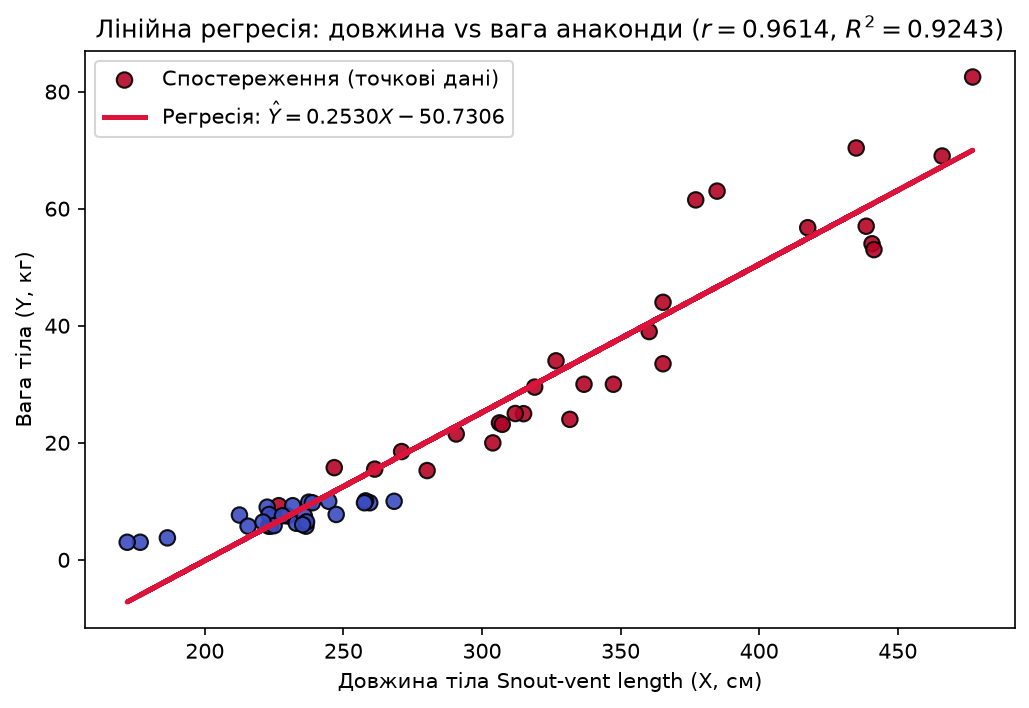

In [5]:
# Побудова графіка регресії
plt.figure(figsize=(8, 5))
plt.scatter(df['X'], df['Y'], c=df['Gender_code'], cmap='coolwarm', s=55, alpha=0.9, edgecolors='k', label='Спостереження (точкові дані)')
plt.plot(df['X'], Y_pred, color='crimson', linewidth=2.4, label=f'Регресія: $\\hat{{Y}} = {slope:.4f}X - {-intercept:.4f}$')
plt.title(f'Лінійна регресія: довжина vs вага анаконди ($r = {r_xy:.4f}$, $R^2 = {r2:.4f}$)')
plt.xlabel('Довжина тіла Snout-vent length (X, см)')
plt.ylabel('Вага тіла (Y, кг)')
plt.legend(frameon=True)
plt.show()

## 6. Аналіз та діагностика залишків (Diagnostic Plots)
**Мета дії:** Обчислити нев'язки (залишки) $e_i = Y_i - \hat{Y}_i$, перевірити виконання умов лінійності, нульового математичного сподівання, гомоскедастичності та нормального розподілу помилок.
$$\rightarrow$$ **Висновок:** Середнє залишків практично нульове ($-8.44 \cdot 10^{-15}$). Проте U-подібна форма залишків та тест Шапіро-Уїлка ($p = 9.67 \cdot 10^{-4} < 0.05$) свідчать про порушення гомоскедастичності та нелінійний характер реальної залежності.

Середнє арифметичне залишків: -8.44e-15
Критерій Шапіро-Уїлка: W = 0.9176, p-value = 9.6736e-04


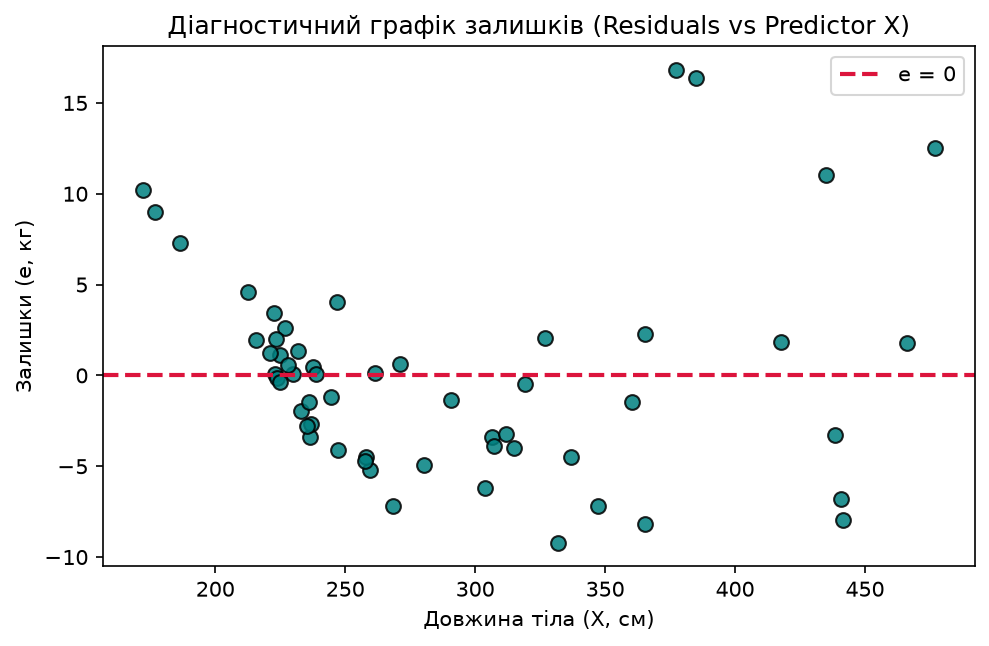

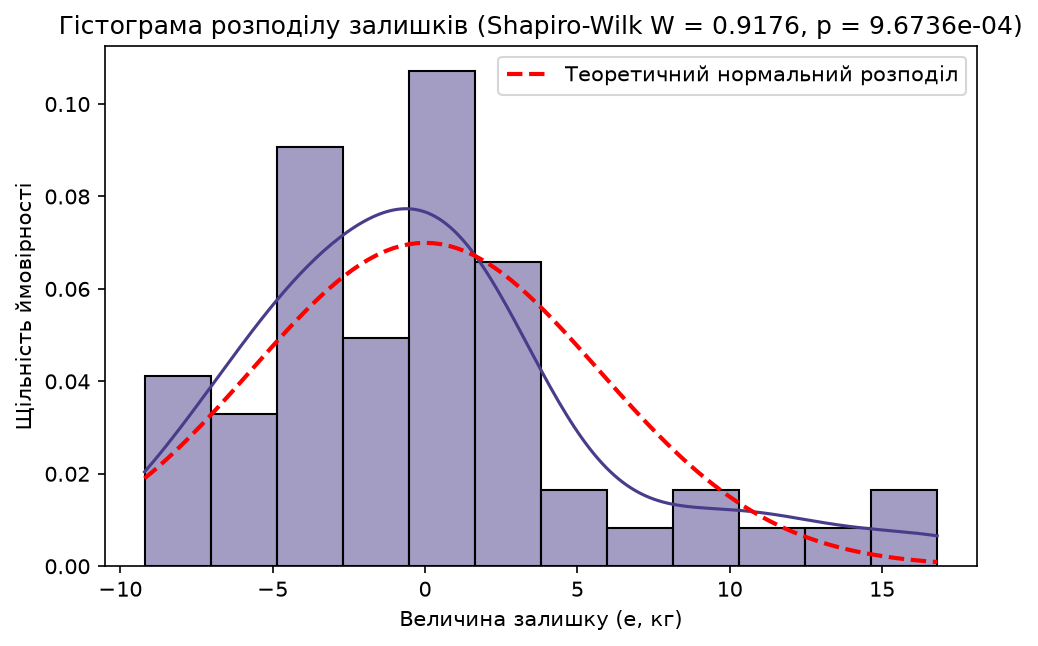

In [6]:
residuals = Y - Y_pred
res_mean = np.mean(residuals)
shapiro_w, shapiro_p = stats.shapiro(residuals)

print(f'Середнє арифметичне залишків: {res_mean:.2e}')
print(f'Критерій Шапіро-Уїлка: W = {shapiro_w:.4f}, p-value = {shapiro_p:.4e}')

# 1. Графік залишків від предиктора
plt.figure(figsize=(7.5, 4.5))
plt.scatter(df['X'], residuals, color='teal', s=50, alpha=0.85, edgecolors='k')
plt.axhline(0, color='crimson', linestyle='--', linewidth=2, label='e = 0')
plt.title('Діагностичний графік залишків (Residuals vs Predictor X)')
plt.xlabel('Довжина тіла (X, см)')
plt.ylabel('Залишки (e, кг)')
plt.legend(frameon=True)
plt.show()

# 2. Гістограма розподілу залишків
plt.figure(figsize=(7.5, 4.5))
sns.histplot(residuals, kde=True, color='darkslateblue', bins=12, stat='density', edgecolor='black')
norm_x = np.linspace(np.min(residuals), np.max(residuals), 100)
norm_y = stats.norm.pdf(norm_x, loc=np.mean(residuals), scale=np.std(residuals, ddof=1))
plt.plot(norm_x, norm_y, 'r--', linewidth=2, label='Теоретичний нормальний розподіл')
plt.title(f'Гістограма розподілу залишків (Shapiro-Wilk W = {shapiro_w:.4f}, p = {shapiro_p:.4e})')
plt.xlabel('Величина залишку (e, кг)')
plt.ylabel('Щільність ймовірності')
plt.legend(frameon=True)
plt.show()

## 7. Дослідження власного числового набору даних (Частина 2: flats.csv)
**Мета дії:** Дослідити взаємозв'язок між загальною площею квартири (м²) та її ринковою ціною (грн), перевірити статистичну значущість зв'язку, побудувати модель парної лінійної регресії та зберегти результуючий графік.
$$\rightarrow$$ **Висновок:** Встановлено помірну статистично достовірну лінійну кореляцію ($r = 0.6729, p = 2.41 \cdot 10^{-91}$); модель пояснює $45.27\%$ варіації вартості ($R^2 = 0.4527$, RMSE $\approx 801\,528$ грн).

Кількість спостережень після фільтрації: 684
Коефіцієнт кореляції Пірсона r = 0.6729, p-value = 2.4082e-91
Рівняння: Ціна = 25180.99 * Площа + (-408119.63)
Коефіцієнт детермінації R^2 = 0.4527
RMSE = 801,528.39 грн


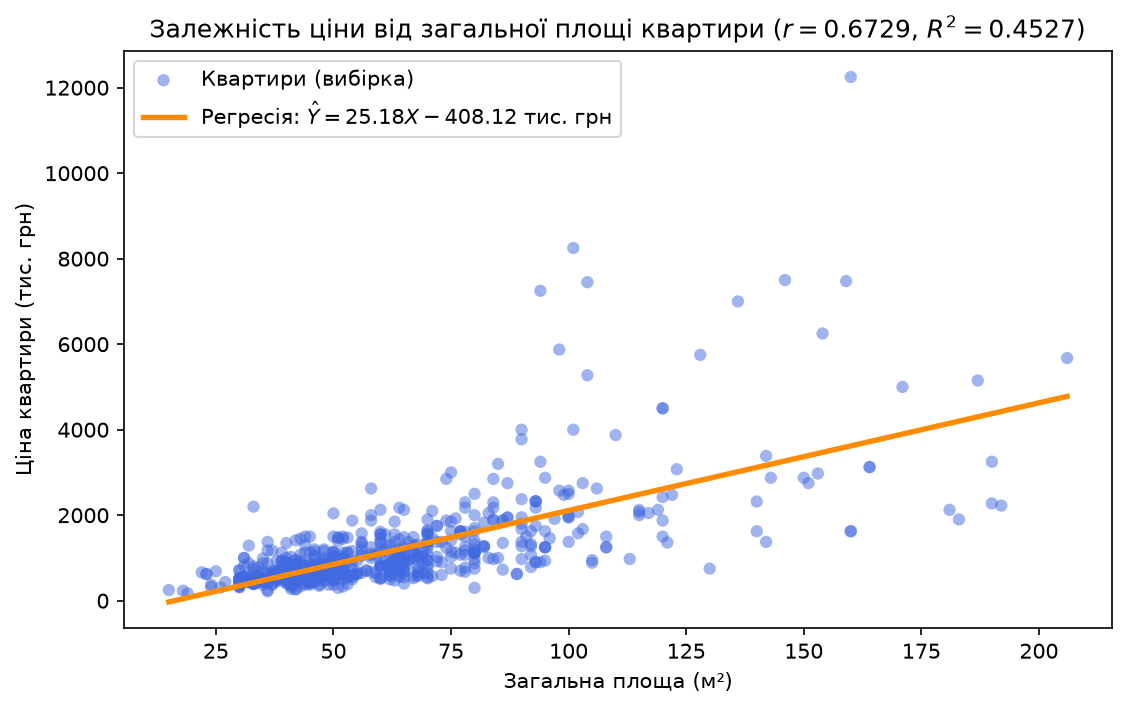

In [7]:
# Завантаження даних ринку нерухомості
flats_file = 'flats.csv'
if not os.path.exists(flats_file):
    if os.path.exists('Lab_1/flats.csv'):
        flats_file = 'Lab_1/flats.csv'
    elif os.path.exists('../Lab_1/flats.csv'):
        flats_file = '../Lab_1/flats.csv'

df_flats = pd.read_csv(flats_file)
area_num = pd.to_numeric(df_flats['Загальна_площа'], errors='coerce')
price_num = pd.to_numeric(df_flats['Ціна'], errors='coerce')

# Фільтрація коректних числових значень
valid_mask = area_num.notna() & price_num.notna()
df_clean = pd.DataFrame({'area': area_num[valid_mask], 'price': price_num[valid_mask]})
df_clean = df_clean[(df_clean['area'] >= 15) & (df_clean['area'] <= 250)]
df_clean = df_clean[(df_clean['price'] >= 100000) & (df_clean['price'] <= 15000000)]
print(f'Кількість спостережень після фільтрації: {len(df_clean)}')

# Кореляційний аналіз
r_val, p_val = stats.pearsonr(df_clean['area'], df_clean['price'])
print(f'Коефіцієнт кореляції Пірсона r = {r_val:.4f}, p-value = {p_val:.4e}')

# Лінійна регресія
X_c = df_clean[['area']].values
Y_c = df_clean['price'].values
model_flats = LinearRegression().fit(X_c, Y_c)
Y_pred_c = model_flats.predict(X_c)

slope_c = float(model_flats.coef_[0])
intercept_c = float(model_flats.intercept_)
r2_c = r2_score(Y_c, Y_pred_c)
rmse_c = np.sqrt(mean_squared_error(Y_c, Y_pred_c))

print(f'Рівняння: Ціна = {slope_c:.2f} * Площа + ({intercept_c:.2f})')
print(f'Коефіцієнт детермінації R^2 = {r2_c:.4f}')
print(f'RMSE = {rmse_c:,.2f} грн')

# Візуалізація
plt.figure(figsize=(8.5, 5))
plt.scatter(df_clean['area'], df_clean['price'] / 1000, color='royalblue', alpha=0.5, s=35, edgecolors='none', label='Квартири (вибірка)')
s_idx = np.argsort(df_clean['area'].values)
plt.plot(df_clean['area'].values[s_idx], (Y_pred_c / 1000)[s_idx], color='darkorange', linewidth=2.6,
         label=f'Регресія: $\\hat{{Y}} = {slope_c/1000:.2f}X - {-intercept_c/1000:.2f}$ тис. грн')
plt.title(f'Залежність ціни від загальної площі квартири ($r = {r_val:.4f}$, $R^2 = {r2_c:.4f}$)')
plt.xlabel('Загальна площа (м²)')
plt.ylabel('Ціна квартири (тис. грн)')
plt.legend(frameon=True)
plt.show()

## 8. Загальний висновок
У ході лабораторної роботи було досліджено властивості лінійного кореляційного та регресійного аналізу:
1. **Датасет anaconda.dat:** виявлено майже функціональний лінійний зв'язок між довжиною тіла та вагою ($r = 0.9614, R^2 = 0.9243$). Проте діагностичний аналіз залишків продемонстрував їх гетероскедастичність та нелінійний U-подібний характер, що узгоджується з кубічним зростанням об'єму тіла тварини.
2. **Власний датасет (нерухомість):** підтверджено статистично значущу лінійну залежність вартості квартири від площі ($r = 0.6729, p < 10^{-90}$); коефіцієнт детермінації становить $R^2 = 0.4527$, що відображає значний вплив інших латентних факторів (район, ремонт, поверх).
3. Освоєно повний цикл побудови регресійних моделей у Python за допомогою `pandas`, `scipy.stats` та `scikit-learn`.